# 自采 EEG 四分类实验：focus / iu / ou / daze

这个 notebook 用来读取同一文件夹下的 `.edf` 文件，并根据文件名自动识别：

- `focus`：专注
- `iu` / `insideunfocus`：内部走神
- `ou` / `outsideunfocus`：外界打扰
- `daze`：发呆

命名规则示例：

```text
focus1.edf        -> self / focus
iu2.edf           -> self / iu
ou1.edf           -> self / ou
daze1.edf         -> self / daze

zyf_focus1.edf    -> zyf / focus
zyf_ou1.edf       -> zyf / ou
zyf_daze1.edf     -> zyf / daze
```

注意：这版先只读取 `.edf`，不读取 `.csv`。


## 0. 需要的库

如果你的环境缺少库，先取消下面这一行注释运行：

```python
# !pip install mne scikit-learn scipy pandas matplotlib
```


In [15]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from scipy.signal import welch

from sklearn.model_selection import train_test_split, StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

print("导入完成")

导入完成


## 1. 修改数据路径和基本参数

把 `DATA_DIR` 改成你存放 EDF 文件的文件夹路径。

例如：

```python
DATA_DIR = Path(r"D:\EEG_data\self_record")
```


In [16]:
# =========================
# 你主要只需要改这里
# =========================
DATA_DIR = Path(r".\data\legacy\multiclass_10min")   # 改成你自己的 EDF 文件夹

# 窗口参数
WINDOW_SEC = 4      # 每个样本窗口 4 秒
STEP_SEC = 2        # 每 2 秒滑动一次

# 频段设置
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 43),
}

LABEL_NAMES = {
    0: "focus",
    1: "iu",
    2: "ou",
    3: "daze",
}

LABEL_TO_ID = {v: k for k, v in LABEL_NAMES.items()}

print("DATA_DIR =", DATA_DIR)

DATA_DIR = data\legacy\multiclass_10min


## 2. 文件名解析函数

这一步会从文件名里自动识别：

- 标签：`focus / iu / ou / daze`
- 被试：没有前缀的是 `self`；有前缀的如 `zyf_focus1.edf` 识别为 `zyf`
- 编号：例如 `focus2.edf` 识别编号为 `2`


In [17]:
def parse_label_from_name(filename: str):
    """
    根据文件名判断四分类标签：
    focus -> 0
    iu / insideunfocus -> 1
    ou / outsideunfocus -> 2
    daze -> 3
    """
    stem = Path(filename).stem.lower()

    # 注意：iu / ou 要放在 focus 前面判断
    # 因为 insideunfocus / outsideunfocus 里面也含有 focus
    if re.search(r"(^|[_\-])iu\d*$", stem) or "insideunfocus" in stem:
        return 1

    if re.search(r"(^|[_\-])ou\d*$", stem) or "outsideunfocus" in stem:
        return 2

    if "daze" in stem or "发呆" in stem:
        return 3

    if "focus" in stem and "unfocus" not in stem:
        return 0

    return None


def parse_subject_from_name(filename: str):
    """
    没有前缀的是自己：self
    有前缀的，比如 zyf_focus1.edf -> zyf
    """
    stem = Path(filename).stem.lower()
    parts = re.split(r"[_\-]", stem)

    # 没有下划线，默认是自己
    if len(parts) == 1:
        return "self"

    first = parts[0]

    # 如果文件名本身就是 focus_1 这种，也算自己
    label_words = {"focus", "iu", "ou", "daze", "insideunfocus", "outsideunfocus"}
    if first in label_words:
        return "self"

    return first


def parse_session_from_name(filename: str):
    """
    提取文件名最后的数字，比如 focus2 -> 2
    提不出来就返回 None
    """
    stem = Path(filename).stem.lower()
    m = re.search(r"(\d+)$", stem)
    if m:
        return int(m.group(1))
    return None


# 简单测试
test_names = ["focus1.edf", "iu2.edf", "ou1.edf", "daze1.edf", "zyf_focus1.edf", "zyf_ou1.edf"]
for name in test_names:
    print(name, "->", parse_subject_from_name(name), LABEL_NAMES.get(parse_label_from_name(name)), parse_session_from_name(name))

focus1.edf -> self focus 1
iu2.edf -> self iu 2
ou1.edf -> self ou 1
daze1.edf -> self daze 1
zyf_focus1.edf -> zyf focus 1
zyf_ou1.edf -> zyf ou 1


## 3. 扫描 EDF 文件并检查标签

先运行这一段，看表格里有没有 `UNKNOWN`。  
如果有，说明某些文件名没有被识别出来，需要改文件名或者改解析规则。


In [18]:
edf_files = sorted(DATA_DIR.glob("*.edf"))

records = []

for f in edf_files:
    label = parse_label_from_name(f.name)
    subject = parse_subject_from_name(f.name)
    session = parse_session_from_name(f.name)

    records.append({
        "file": f.name,
        "path": str(f),
        "subject": subject,
        "session": session,
        "label": label,
        "label_name": LABEL_NAMES.get(label, "UNKNOWN"),
    })

df_files = pd.DataFrame(records)

print("找到 EDF 文件数量:", len(df_files))

if len(df_files) == 0:
    print("没有找到 EDF 文件。请检查 DATA_DIR 路径是否正确。")

df_files

找到 EDF 文件数量: 26


,file,path,subject,session,label,label_name
0,daze1.edf,data\legacy\multiclass_10min\daze1.edf,self,1,3,daze
1,daze2.edf,data\legacy\multiclass_10min\daze2.edf,self,2,3,daze
2,focus1.edf,data\legacy\multiclass_10min\focus1.edf,self,1,0,focus
3,focus2.edf,data\legacy\multiclass_10min\focus2.edf,self,2,0,focus
4,focus3.edf,data\legacy\multiclass_10min\focus3.edf,self,3,0,focus
5,focus4.edf,data\legacy\multiclass_10min\focus4.edf,self,4,0,focus
6,focus5.edf,data\legacy\multiclass_10min\focus5.edf,self,5,0,focus
7,focus6.edf,data\legacy\multiclass_10min\focus6.edf,self,6,0,focus
8,iu1.edf,data\legacy\multiclass_10min\iu1.edf,self,1,1,iu
9,iu2.edf,data\legacy\multiclass_10min\iu2.edf,self,2,1,iu


In [19]:
print("标签数量：")
display(df_files["label_name"].value_counts(dropna=False))

print("\n按被试 × 标签统计：")
display(df_files.groupby(["subject", "label_name"]).size().unstack(fill_value=0))

unknown_files = df_files[df_files["label"].isna()]
if len(unknown_files) > 0:
    print("\n下面这些文件没有识别出标签，请先处理：")
    display(unknown_files[["file", "subject", "label_name"]])
else:
    print("\n所有文件都识别出标签了，可以继续。")

标签数量：


label_name
focus    10
iu        6
ou        6
daze      4
Name: count, dtype: int64


按被试 × 标签统计：


label_name,daze,focus,iu,ou
subject,,,,
self,2,6,4,3
zyf,2,4,2,3



所有文件都识别出标签了，可以继续。


## 4. 特征提取函数

这里暂时使用一个比较稳的特征：**各通道各频段功率**。

每个窗口会提取：

- delta：1–4 Hz
- theta：4–8 Hz
- alpha：8–13 Hz
- beta：13–30 Hz
- gamma：30–43 Hz

每个频段同时提取：

- log 绝对功率
- 相对功率

所以如果有 8 个 EEG 通道，特征数就是：

```text
8 通道 × 5 频段 × 2 种功率 = 80 个特征
```


In [20]:
def bandpower_features(window_data, sfreq, bands):
    """
    window_data: shape = [n_channels, n_times]
    返回一个一维特征向量
    """
    features = []

    for ch_data in window_data:
        freqs, psd = welch(
            ch_data,
            fs=sfreq,
            nperseg=min(len(ch_data), int(sfreq * 2))
        )

        total_idx = (freqs >= 1) & (freqs <= 43)
        total_power = np.trapezoid(psd[total_idx], freqs[total_idx]) + 1e-12

        for band_name, (low, high) in bands.items():
            idx = (freqs >= low) & (freqs < high)
            power = np.trapezoid(psd[idx], freqs[idx]) + 1e-12

            # log 绝对功率
            features.append(np.log(power))

            # 相对功率
            features.append(power / total_power)

    return np.array(features)


def extract_features_from_edf(edf_path, label, subject, file_id):
    """
    读取一个 EDF，切成多个窗口，每个窗口提取频段功率特征
    """
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

    # 只保留 EEG 通道
    raw.pick_types(eeg=True, stim=False, misc=False, verbose=False)

    if len(raw.ch_names) == 0:
        raise ValueError(f"{edf_path} 没有识别到 EEG 通道")

    sfreq = float(raw.info["sfreq"])

    # 带通滤波
    raw.filter(
        l_freq=0.5,
        h_freq=43,
        fir_design="firwin",
        verbose=False
    )

    data = raw.get_data()  # shape = [n_channels, n_times]

    window_size = int(WINDOW_SEC * sfreq)
    step_size = int(STEP_SEC * sfreq)

    X_list = []
    y_list = []
    subject_list = []
    file_group_list = []
    window_start_sec_list = []

    n_times = data.shape[1]

    for start in range(0, n_times - window_size + 1, step_size):
        stop = start + window_size
        window = data[:, start:stop]

        feat = bandpower_features(window, sfreq, BANDS)

        X_list.append(feat)
        y_list.append(label)
        subject_list.append(subject)
        file_group_list.append(file_id)
        window_start_sec_list.append(start / sfreq)

    return {
        "X": X_list,
        "y": y_list,
        "subjects": subject_list,
        "file_groups": file_group_list,
        "window_start_sec": window_start_sec_list,
        "ch_names": raw.ch_names,
        "sfreq": sfreq,
        "duration_sec": n_times / sfreq,
    }

## 5. 批量读取全部 EDF 并生成窗口样本

这一步可能会花一点时间。  
如果某个文件报错，它会记录到 `errors`，不会让整个 notebook 崩掉。


In [21]:
X_all = []
y_all = []
subjects_all = []
file_groups_all = []
window_start_sec_all = []

file_info = []
errors = []

valid_df = df_files[df_files["label"].notna()].copy()

for idx, row in valid_df.iterrows():
    print("读取中:", row["file"], "| 标签:", row["label_name"], "| 被试:", row["subject"])

    try:
        result = extract_features_from_edf(
            edf_path=row["path"],
            label=int(row["label"]),
            subject=row["subject"],
            file_id=row["file"]
        )

        X_all.extend(result["X"])
        y_all.extend(result["y"])
        subjects_all.extend(result["subjects"])
        file_groups_all.extend(result["file_groups"])
        window_start_sec_all.extend(result["window_start_sec"])

        file_info.append({
            "file": row["file"],
            "subject": row["subject"],
            "label_name": row["label_name"],
            "n_windows": len(result["X"]),
            "n_channels": len(result["ch_names"]),
            "sfreq": result["sfreq"],
            "duration_sec": result["duration_sec"],
            "channels": ", ".join(result["ch_names"]),
        })

    except Exception as e:
        errors.append({
            "file": row["file"],
            "error": repr(e),
        })
        print("  读取失败:", repr(e))

X = np.array(X_all)
y = np.array(y_all)
subjects = np.array(subjects_all)
file_groups = np.array(file_groups_all)
window_start_sec = np.array(window_start_sec_all)

df_info = pd.DataFrame(file_info)
df_errors = pd.DataFrame(errors)

print("\n完成")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)
print("file_groups shape:", file_groups.shape)

if len(df_errors) > 0:
    print("\n有文件读取失败：")
    display(df_errors)

df_info

读取中: daze1.edf | 标签: daze | 被试: self
读取中: daze2.edf | 标签: daze | 被试: self
读取中: focus1.edf | 标签: focus | 被试: self
读取中: focus2.edf | 标签: focus | 被试: self
读取中: focus3.edf | 标签: focus | 被试: self
读取中: focus4.edf | 标签: focus | 被试: self
读取中: focus5.edf | 标签: focus | 被试: self
读取中: focus6.edf | 标签: focus | 被试: self
读取中: iu1.edf | 标签: iu | 被试: self
读取中: iu2.edf | 标签: iu | 被试: self
读取中: iu3.edf | 标签: iu | 被试: self
读取中: iu4.edf | 标签: iu | 被试: self
读取中: ou1.edf | 标签: ou | 被试: self
读取中: ou2.edf | 标签: ou | 被试: self
读取中: ou3.edf | 标签: ou | 被试: self
读取中: zyf_daze1.edf | 标签: daze | 被试: zyf
读取中: zyf_daze2.edf | 标签: daze | 被试: zyf
读取中: zyf_focus1.edf | 标签: focus | 被试: zyf
读取中: zyf_focus2.edf | 标签: focus | 被试: zyf
读取中: zyf_focus3.edf | 标签: focus | 被试: zyf
读取中: zyf_focus4.edf | 标签: focus | 被试: zyf
读取中: zyf_iu1.edf | 标签: iu | 被试: zyf
读取中: zyf_iu2.edf | 标签: iu | 被试: zyf
读取中: zyf_ou1.edf | 标签: ou | 被试: zyf
读取中: zyf_ou2.edf | 标签: ou | 被试: zyf
读取中: zyf_ou3.edf | 标签: ou | 被试: zyf

完成
X shape: (7934, 240)
y shape:

,file,subject,label_name,n_windows,n_channels,sfreq,duration_sec,channels
0,daze1.edf,self,daze,298,24,300.0,599.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."
1,daze2.edf,self,daze,298,24,300.0,599.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."
2,focus1.edf,self,focus,298,24,300.0,599.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."
3,focus2.edf,self,focus,298,24,300.0,599.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."
4,focus3.edf,self,focus,451,24,300.0,905.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."
5,focus4.edf,self,focus,324,24,300.0,650.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."
6,focus5.edf,self,focus,298,24,300.0,599.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."
7,focus6.edf,self,focus,298,24,300.0,599.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."
8,iu1.edf,self,iu,298,24,300.0,599.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."
9,iu2.edf,self,iu,298,24,300.0,599.5,"EEG P3-Pz, EEG C3-Pz, EEG F3-Pz, EEG Fz-Pz, EE..."


In [22]:
if len(y) > 0:
    print("窗口级标签分布：")
    display(pd.Series(y).map(LABEL_NAMES).value_counts())

    print("\n文件级信息：")
    display(df_info[["file", "subject", "label_name", "n_windows", "n_channels", "sfreq", "duration_sec"]])

    print("\n每个文件的窗口数量：")
    display(df_info.groupby(["subject", "label_name"])["n_windows"].sum().unstack(fill_value=0))
else:
    print("没有成功提取出任何窗口样本，请检查前面的错误信息。")

窗口级标签分布：


focus    3166
iu       1788
ou       1788
daze     1192
Name: count, dtype: int64


文件级信息：


,file,subject,label_name,n_windows,n_channels,sfreq,duration_sec
0,daze1.edf,self,daze,298,24,300.0,599.5
1,daze2.edf,self,daze,298,24,300.0,599.5
2,focus1.edf,self,focus,298,24,300.0,599.5
3,focus2.edf,self,focus,298,24,300.0,599.5
4,focus3.edf,self,focus,451,24,300.0,905.5
5,focus4.edf,self,focus,324,24,300.0,650.5
6,focus5.edf,self,focus,298,24,300.0,599.5
7,focus6.edf,self,focus,298,24,300.0,599.5
8,iu1.edf,self,iu,298,24,300.0,599.5
9,iu2.edf,self,iu,298,24,300.0,599.5



每个文件的窗口数量：


label_name,daze,focus,iu,ou
subject,,,,
self,596,1967,1192,894
zyf,596,1199,596,894


## 6. 建立模型

这里使用：

```text
StandardScaler -> PCA -> SVM
```

- `StandardScaler`：标准化特征
- `PCA(n_components=0.95)`：保留 95% 方差信息
- `SVC(kernel="rbf")`：RBF 核 SVM 分类器
- `class_weight="balanced"`：缓解类别样本数不完全一致的问题


In [23]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('svm',
                 SVC(C=10, class_weight='balanced', probability=True,
                     random_state=42))])


## 7. 实验一：随机窗口划分

这个结果一般会偏高，因为同一个 EDF 文件里的相邻窗口很像。

它主要用来检查：

- 代码能不能跑通
- 特征有没有学到东西
- 四类之间有没有初步差异

不要把这个结果当成真实泛化能力。


类别数量: {'focus': np.int64(3166), 'iu': np.int64(1788), 'ou': np.int64(1788), 'daze': np.int64(1192)}
随机窗口划分准确率: 0.9420289855072463

              precision    recall  f1-score   support

       focus       0.96      0.97      0.96       633
          iu       0.90      0.88      0.89       358
          ou       0.93      0.94      0.94       358
        daze       0.99      0.97      0.98       238

    accuracy                           0.94      1587
   macro avg       0.94      0.94      0.94      1587
weighted avg       0.94      0.94      0.94      1587



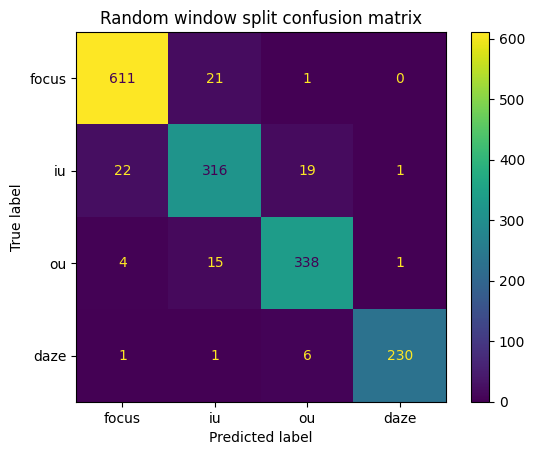

In [24]:
if len(y) == 0:
    print("没有数据，无法训练。")
else:
    unique_labels, label_counts = np.unique(y, return_counts=True)
    print("类别数量:", dict(zip([LABEL_NAMES[i] for i in unique_labels], label_counts)))

    can_stratify = np.all(label_counts >= 2)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y if can_stratify else None
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("随机窗口划分准确率:", accuracy_score(y_test, y_pred))
    print()
    print(classification_report(
        y_test,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=[LABEL_NAMES[i] for i in [0, 1, 2, 3]],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[LABEL_NAMES[i] for i in [0, 1, 2, 3]]
    )
    disp.plot()
    plt.title("Random window split confusion matrix")
    plt.show()

## 8. 实验二：按 EDF 文件分组划分

这个比随机窗口划分更有参考价值。

它保证：

```text
同一个 EDF 文件切出来的窗口，不会同时进入训练集和测试集
```

也就是说，测试集更像是“新录的一段数据”。


文件级标签数量：


label
focus    10
iu        6
ou        6
daze      4
Name: count, dtype: int64

n_splits = 3
Fold 1
测试文件:
  daze1.edf
  focus3.edf
  iu2.edf
  iu3.edf
  zyf_daze1.edf
  zyf_focus1.edf
  zyf_focus3.edf
  zyf_ou1.edf
  zyf_ou3.edf
测试集标签分布:
focus    1047
daze      596
iu        596
ou        596
Name: count, dtype: int64
Fold accuracy: 0.43527336860670196
Fold 2
测试文件:
  focus2.edf
  focus4.edf
  focus6.edf
  iu4.edf
  ou1.edf
  ou2.edf
  zyf_daze2.edf
  zyf_iu2.edf
测试集标签分布:
focus    920
iu       596
ou       596
daze     298
Name: count, dtype: int64
Fold accuracy: 0.34107883817427387
Fold 3
测试文件:
  daze2.edf
  focus1.edf
  focus5.edf
  iu1.edf
  ou3.edf
  zyf_focus2.edf
  zyf_focus4.edf
  zyf_iu1.edf
  zyf_ou2.edf
测试集标签分布:
focus    1199
iu        596
ou        596
daze      298
Name: count, dtype: int64
Fold accuracy: 0.4484938638899219
按文件分组交叉验证总体准确率: 0.41114192084698764

              precision    recall  f1-score   support

       focus       0.62      0.57      0.59      3166
          iu       0.17      0.23      0.20      1788
          ou       0.27      0.26

,fold,accuracy,test_files
0,1,0.435273,"daze1.edf, focus3.edf, iu2.edf, iu3.edf, zyf_d..."
1,2,0.341079,"focus2.edf, focus4.edf, focus6.edf, iu4.edf, o..."
2,3,0.448494,"daze2.edf, focus1.edf, focus5.edf, iu1.edf, ou..."


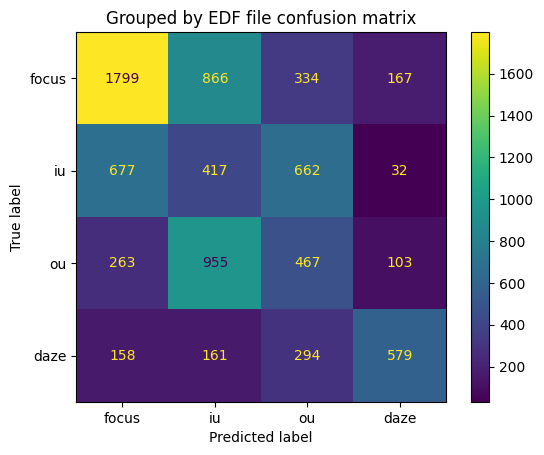

In [25]:
if len(y) == 0:
    print("没有数据，无法训练。")
else:
    file_label_df = pd.DataFrame({
        "file": file_groups,
        "label": y
    }).drop_duplicates()

    print("文件级标签数量：")
    display(file_label_df["label"].map(LABEL_NAMES).value_counts())

    min_class_files = file_label_df["label"].value_counts().min()
    n_splits = min(3, int(min_class_files))

    print("n_splits =", n_splits)

    if n_splits < 2:
        print("某个类别的 EDF 文件数少于 2，暂时不能做 StratifiedGroupKFold。")
    else:
        sgkf = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=42
        )

        all_true = []
        all_pred = []
        fold_results = []

        for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups=file_groups), start=1):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            train_files = np.unique(file_groups[train_idx])
            test_files = np.unique(file_groups[test_idx])

            print("=" * 80)
            print(f"Fold {fold}")
            print("测试文件:")
            for f in test_files:
                print(" ", f)

            print("测试集标签分布:")
            print(pd.Series(y_test).map(LABEL_NAMES).value_counts())

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            print("Fold accuracy:", acc)

            fold_results.append({
                "fold": fold,
                "accuracy": acc,
                "test_files": ", ".join(test_files)
            })

            all_true.extend(y_test)
            all_pred.extend(y_pred)

        all_true = np.array(all_true)
        all_pred = np.array(all_pred)
        df_fold_results = pd.DataFrame(fold_results)

        print("=" * 80)
        print("按文件分组交叉验证总体准确率:", accuracy_score(all_true, all_pred))
        print()
        print(classification_report(
            all_true,
            all_pred,
            labels=[0, 1, 2, 3],
            target_names=[LABEL_NAMES[i] for i in [0, 1, 2, 3]],
            zero_division=0
        ))

        display(df_fold_results)

        cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2, 3])
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[LABEL_NAMES[i] for i in [0, 1, 2, 3]]
        )
        disp.plot()
        plt.title("Grouped by EDF file confusion matrix")
        plt.show()

## 9. 实验三：按被试留一法

现在只有两个被试，所以这个结果会非常不稳定。

尤其是如果某个同学没有录完整四类，那么训练集可能缺某个类别。  
所以这个实验现在只能作为观察，不能作为主要结论。


被试: ['self' 'zyf']
Fold 1
训练被试: ['zyf']
测试被试: ['self']
训练集标签分布:
focus    1199
ou        894
daze      596
iu        596
Name: count, dtype: int64
测试集标签分布:
focus    1967
iu       1192
ou        894
daze      596
Name: count, dtype: int64
Accuracy: 0.15766831576683157
Fold 2
训练被试: ['self']
测试被试: ['zyf']
训练集标签分布:
focus    1967
iu       1192
ou        894
daze      596
Name: count, dtype: int64
测试集标签分布:
focus    1199
ou        894
daze      596
iu        596
Name: count, dtype: int64
Accuracy: 0.2115677321156773
按被试留一法总体准确率: 0.1799848752205697

              precision    recall  f1-score   support

       focus       0.46      0.13      0.20      3166
          iu       0.18      0.21      0.19      1788
          ou       0.03      0.01      0.01      1788
        daze       0.15      0.54      0.23      1192

    accuracy                           0.18      7934
   macro avg       0.20      0.22      0.16      7934
weighted avg       0.25      0.18      0.16      7934



,fold,test_subject,accuracy
0,1,self,0.157668
1,2,zyf,0.211568


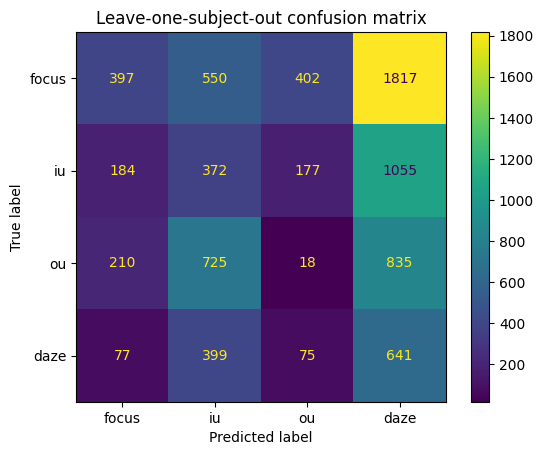

In [26]:
if len(y) == 0:
    print("没有数据，无法训练。")
else:
    unique_subjects = np.unique(subjects)
    print("被试:", unique_subjects)

    if len(unique_subjects) < 2:
        print("被试数量不足，不能做按被试留一法。")
    else:
        logo = LeaveOneGroupOut()

        all_true_subj = []
        all_pred_subj = []
        subject_fold_results = []

        for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=subjects), start=1):
            test_subject = np.unique(subjects[test_idx])
            train_subject = np.unique(subjects[train_idx])

            print("=" * 80)
            print(f"Fold {fold}")
            print("训练被试:", train_subject)
            print("测试被试:", test_subject)

            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            print("训练集标签分布:")
            print(pd.Series(y_train).map(LABEL_NAMES).value_counts())
            print("测试集标签分布:")
            print(pd.Series(y_test).map(LABEL_NAMES).value_counts())

            if len(np.unique(y_train)) < 2:
                print("训练集类别少于 2，跳过这个 fold。")
                continue

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            print("Accuracy:", acc)

            subject_fold_results.append({
                "fold": fold,
                "test_subject": ", ".join(test_subject),
                "accuracy": acc,
            })

            all_true_subj.extend(y_test)
            all_pred_subj.extend(y_pred)

        if len(all_true_subj) > 0:
            all_true_subj = np.array(all_true_subj)
            all_pred_subj = np.array(all_pred_subj)

            print("=" * 80)
            print("按被试留一法总体准确率:", accuracy_score(all_true_subj, all_pred_subj))
            print()
            print(classification_report(
                all_true_subj,
                all_pred_subj,
                labels=[0, 1, 2, 3],
                target_names=[LABEL_NAMES[i] for i in [0, 1, 2, 3]],
                zero_division=0
            ))

            display(pd.DataFrame(subject_fold_results))

            cm = confusion_matrix(all_true_subj, all_pred_subj, labels=[0, 1, 2, 3])
            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=[LABEL_NAMES[i] for i in [0, 1, 2, 3]]
            )
            disp.plot()
            plt.title("Leave-one-subject-out confusion matrix")
            plt.show()
        else:
            print("没有可用的被试留一结果。")

## 10. 保存特征，方便下次不用重新读取 EDF

如果 EDF 读取和滤波比较慢，可以把特征保存下来。  
下次可以直接加载 `.npz` 文件。


In [27]:
if len(y) > 0:
    save_path = Path(r".\artifacts\legacy\notebook_outputs\multiclass_10min\four_class_features_cache.npz")

    np.savez(
        save_path,
        X=X,
        y=y,
        subjects=subjects,
        file_groups=file_groups,
        window_start_sec=window_start_sec,
    )

    print("已保存特征到：", save_path)
else:
    print("没有数据，不保存。")

已保存特征到： data\legacy\multiclass_10min\four_class_features_cache.npz


In [28]:
# 下次如果想直接加载特征，可以运行这一段
# cache_path = Path(r".\artifacts\legacy\notebook_outputs\multiclass_10min\four_class_features_cache.npz")
# cache = np.load(cache_path, allow_pickle=True)
# X = cache["X"]
# y = cache["y"]
# subjects = cache["subjects"]
# file_groups = cache["file_groups"]
# window_start_sec = cache["window_start_sec"]
#
# print("X shape:", X.shape)
# print("y shape:", y.shape)

## 11. 当前阶段怎么看结果

你现在优先看这几个东西：

1. `df_files`：文件名识别对不对，有没有 `UNKNOWN`
2. `df_info`：每个文件的通道数、采样率、窗口数量是不是正常
3. 随机窗口划分：只看流程能不能跑通，不要过度相信准确率
4. 按文件分组划分：比随机窗口更可信
5. 被试留一法：现在只有两个被试，而且类别不完整，只能观察，不能下正式结论

如果按文件分组结果很低，不一定是代码错。  
现在数据少、被试少、类别还没完全平衡，低是正常的。先把流程跑通，再补数据。
